Centroids:
 [[43.2 16.7]
 [29.6 66.8]
 [55.1 46.9]]


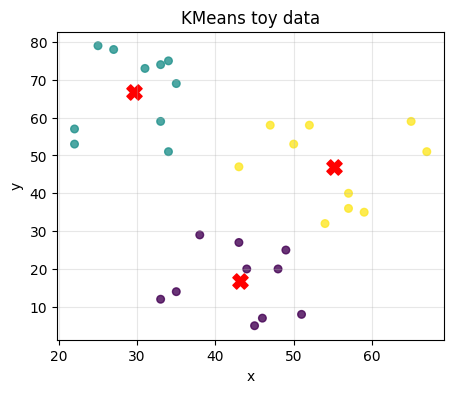

In [1]:
# KMeans 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Dữ liệu toy 2D
X = np.array([
    [25,79],[34,51],[22,53],[27,78],[33,59],[33,74],[31,73],[22,57],[35,69],[34,75],
    [67,51],[54,32],[57,40],[43,47],[50,53],[57,36],[59,35],[52,58],[65,59],[47,58],
    [49,25],[48,20],[35,14],[33,12],[44,20],[45,5],[38,29],[43,27],[51,8],[46,7]
])

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans.fit(X)
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

print('Centroids:\n', centroids)

plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c=labels.astype(float), s=30, alpha=0.8)
plt.scatter(centroids[:,0], centroids[:,1], c='red', s=120, marker='X')
plt.title('KMeans toy data')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()


   support          itemsets
0      0.8         (bánh mì)
1      0.6              (bơ)
2      0.6             (sữa)
3      0.4           (trứng)
4      0.4     (bánh mì, bơ)
5      0.4    (bánh mì, sữa)
6      0.4  (trứng, bánh mì)
  antecedents consequents  support  confidence  lift
0     (trứng)   (bánh mì)      0.4         1.0  1.25
1   (bánh mì)     (trứng)      0.4         0.5  1.25

Top 5 theo lift:
  antecedents consequents  support  confidence  lift
0     (trứng)   (bánh mì)      0.4         1.0  1.25
1   (bánh mì)     (trứng)      0.4         0.5  1.25


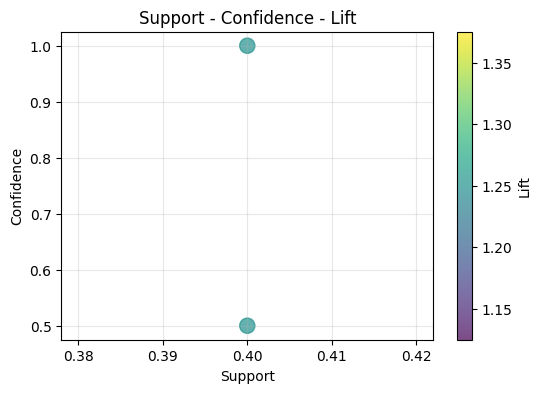

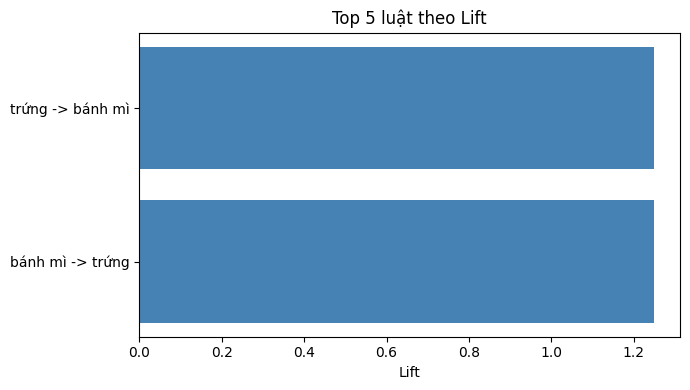

In [2]:
# Association Rules (TransactionEncoder + apriori)
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt

# Ví dụ dữ liệu nhỏ
dataset = [
    ['sữa', 'bánh mì', 'trứng'],
    ['sữa', 'bánh mì'],
    ['bánh mì', 'bơ'],
    ['sữa', 'bơ'],
    ['trứng', 'bơ', 'bánh mì']
]

# One-hot
te = TransactionEncoder()
te_data = te.fit_transform(dataset)
df = pd.DataFrame(te_data, columns=te.columns_)

# Frequent itemsets và rules
frequent_itemsets = apriori(df, min_support=0.4, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
print(frequent_itemsets)
print(rules[['antecedents','consequents','support','confidence','lift']])

# Top 5 theo lift
top5_lift = rules.sort_values(by='lift', ascending=False).head(5)
print('\nTop 5 theo lift:')
print(top5_lift[['antecedents','consequents','support','confidence','lift']])

# Scatter support-confidence, màu theo lift
plt.figure(figsize=(6,4))
sc = plt.scatter(rules['support'], rules['confidence'], c=rules['lift'], cmap='viridis', s=120, alpha=0.7)
plt.colorbar(sc, label='Lift')
plt.title('Support - Confidence - Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid(True, alpha=0.3)
plt.show()

# Barh top 5 lift
plt.figure(figsize=(7,4))
labels = [f"{', '.join(map(str,a))} -> {', '.join(map(str,b))}" for a,b in zip(top5_lift['antecedents'], top5_lift['consequents'])]
plt.barh(range(len(top5_lift)), top5_lift['lift'], color='steelblue')
plt.yticks(range(len(top5_lift)), labels)
plt.xlabel('Lift')
plt.title('Top 5 luật theo Lift')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [3]:
# PCA (theo hình PCA + StandardScaler + explained variance)
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Dữ liệu mẫu 3 biến
df = pd.DataFrame({
    'x1': [1,2,3,4,5],
    'x2': [2,4,6,8,10],
    'x3': [5,3,6,2,8],
})

# 1) Chuẩn hóa
df_std = StandardScaler().fit_transform(df)

# 2) PCA
pca_out = PCA().fit(df_std)
print('explained_variance_ratio_:', pca_out.explained_variance_ratio_)
print('cumsum:', np.cumsum(pca_out.explained_variance_ratio_))


explained_variance_ratio_: [7.28351154e-01 2.71648846e-01 1.22229232e-32]
cumsum: [0.72835115 1.         1.        ]
